<a href="https://www.kaggle.com/code/subhadiphensh/fashion-mnist-fnn-model?scriptVersionId=286515520" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install "protobuf<4" --no-deps -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import platform
import math

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.datasets import fashion_mnist
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

2025-12-16 07:39:33.018537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765870773.225968      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765870773.289788      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print(f"Python Version : {platform.python_version()}")
print(f'Tensorflow Version : {tf.__version__}')
print(f"Keras Version : {tf.keras.__version__}")

Python Version : 3.11.13
Tensorflow Version : 2.18.0
Keras Version : 3.8.0


In [4]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape}")

X_train : (60000, 28, 28)
y_train : (60000,)
X_test : (10000, 28, 28)
y_test : (10000,)


In [6]:
(_, IMAGE_WIDTH, IMAGE_HEIGHT) = X_train.shape
IMAGE_CHANNELS = 1

print(f"IMAGE_WIDTH : {IMAGE_WIDTH}")
print(f"IMAGE_HEIGHT : {IMAGE_HEIGHT}")
print(f"IMAGE_CHANNELS : {IMAGE_CHANNELS}")

IMAGE_WIDTH : 28
IMAGE_HEIGHT : 28
IMAGE_CHANNELS : 1


In [7]:
pd.set_option("display.max_columns", None)

In [8]:
pd.DataFrame(X_train[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,13,73,0,0,1,4,0,0,0,0,1,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,3,0,36,136,127,62,54,0,0,0,1,3,4,0,0,3
5,0,0,0,0,0,0,0,0,0,0,0,0,6,0,102,204,176,134,144,123,23,0,0,0,0,12,10,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,155,236,207,178,107,156,161,109,64,23,77,130,72,15
7,0,0,0,0,0,0,0,0,0,0,0,1,0,69,207,223,218,216,216,163,127,121,122,146,141,88,172,66
8,0,0,0,0,0,0,0,0,0,1,1,1,0,200,232,232,233,229,223,223,215,213,164,127,123,196,229,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,183,225,216,223,228,235,227,224,222,224,221,223,245,173,0


In [9]:
pd.DataFrame(X_test[0])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,1,0,0,7,0,37,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,27,84,11,0,0,0,0,0,0,119,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,88,143,110,0,0,0,0,22,93,106,0,0


In [10]:
plt.style.use('dark_background')

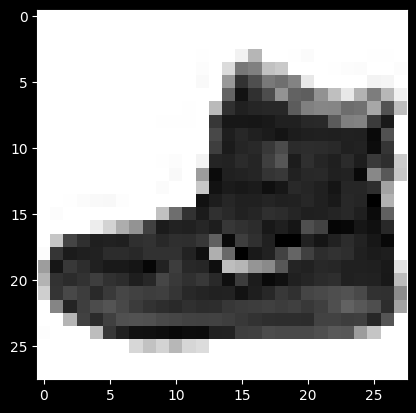

In [11]:
plt.imshow(X_train[0], cmap = plt.cm.binary)
plt.show()

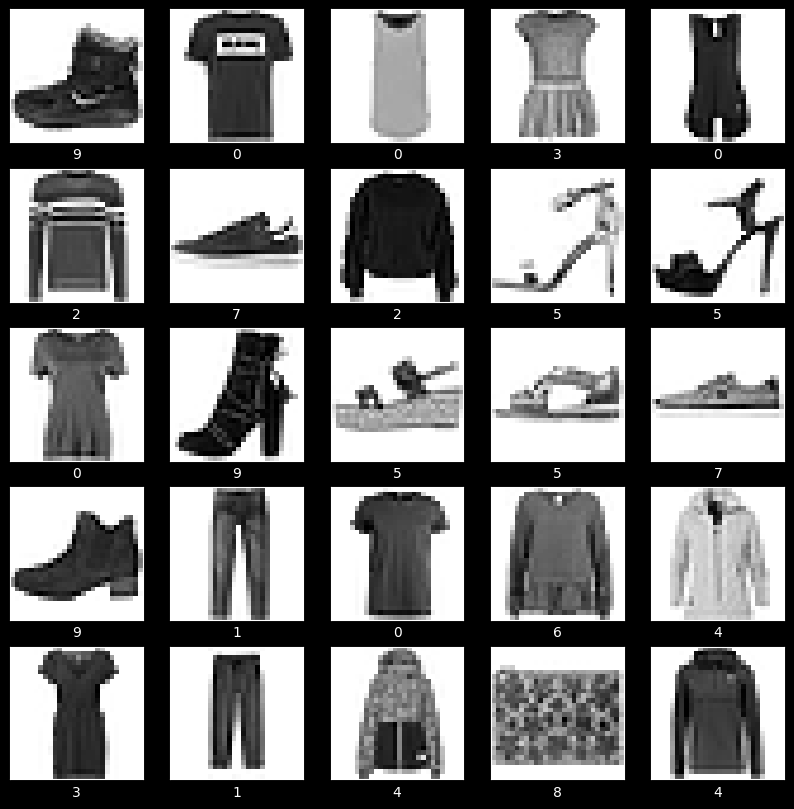

In [12]:
numbers_to_display = 25

num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize = (10,10))

for i in range(numbers_to_display):
    plt.subplot(num_cells, num_cells, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap = plt.cm.binary)
    plt.xlabel(y_train[i])

plt.show()

In [13]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

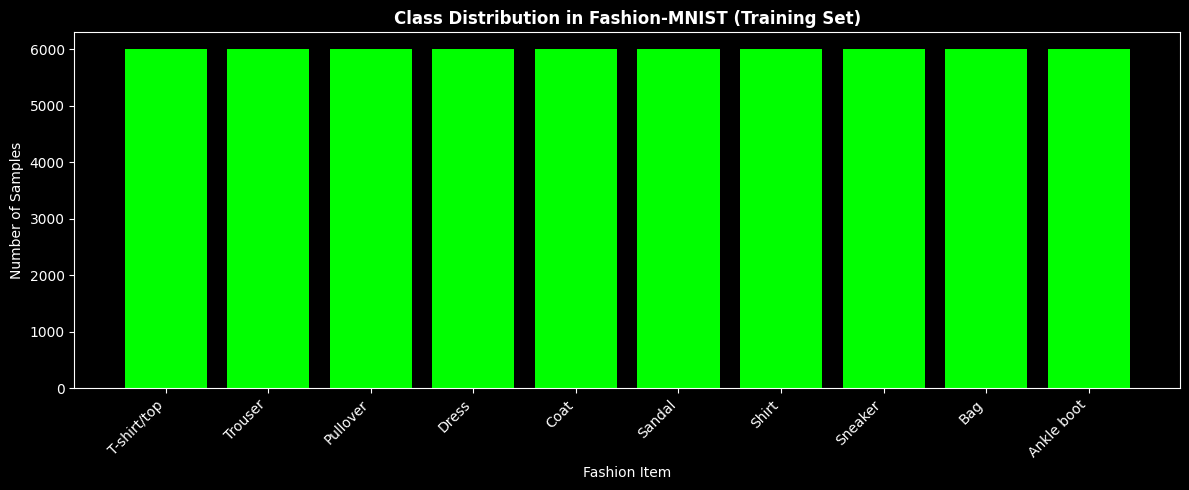

In [14]:
unique, counts = np.unique(y_train, return_counts = True)

plt.figure(figsize = (12, 5))
plt.bar(class_names, counts, color = 'Lime')
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel("Fashion Item")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Fashion-MNIST (Training Set)", fontweight = "semibold")
plt.tight_layout()
plt.show()

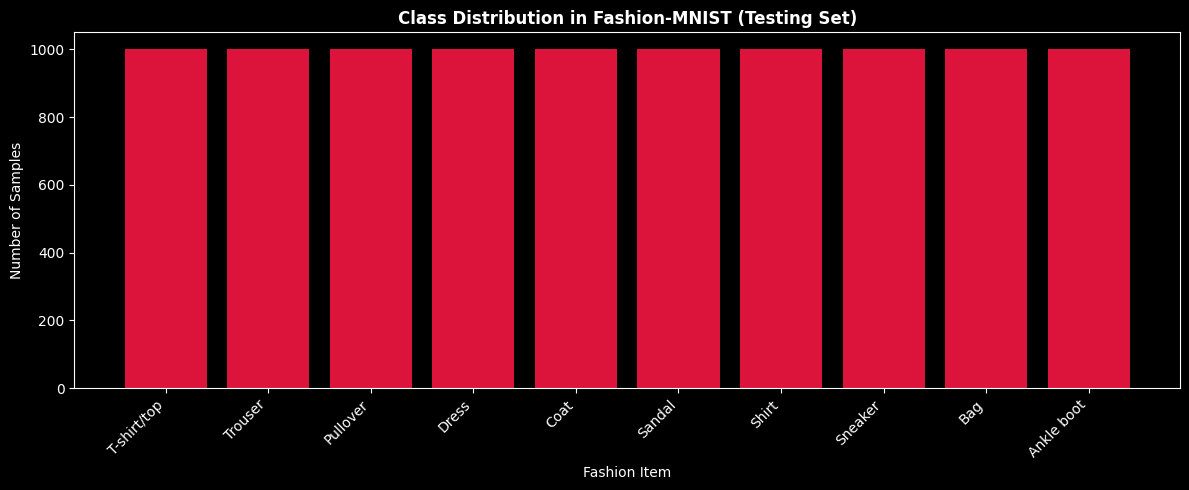

In [15]:
unique, counts = np.unique(y_test, return_counts = True)

plt.figure(figsize = (12, 5))
plt.bar(class_names, counts, color = 'Crimson')
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel("Fashion Item")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Fashion-MNIST (Testing Set)", fontweight = "semibold")
plt.tight_layout()
plt.show()

In [16]:
X_train_with_channels = X_train.reshape(
    X_train.shape[0],
    IMAGE_WIDTH,
    IMAGE_HEIGHT,
    IMAGE_CHANNELS
)

X_test_with_channels = X_test.reshape(
    X_test.shape[0],
    IMAGE_WIDTH,
    IMAGE_HEIGHT,
    IMAGE_CHANNELS
)

In [17]:
print(f"X_train_with_channels : {X_train_with_channels.shape}")
print(f"X_Test_with_channels : {X_test_with_channels.shape}")

X_train_with_channels : (60000, 28, 28, 1)
X_Test_with_channels : (10000, 28, 28, 1)


In [18]:
X_train_normalized = X_train_with_channels / 255.
X_test_normalized = X_test_with_channels / 255.

In [19]:
X_train_normalized[0][18]

array([[0.01176471],
       [0.79215686],
       [0.89411765],
       [0.87843137],
       [0.86666667],
       [0.82745098],
       [0.82745098],
       [0.83921569],
       [0.80392157],
       [0.80392157],
       [0.80392157],
       [0.8627451 ],
       [0.94117647],
       [0.31372549],
       [0.58823529],
       [1.        ],
       [0.89803922],
       [0.86666667],
       [0.7372549 ],
       [0.60392157],
       [0.74901961],
       [0.82352941],
       [0.8       ],
       [0.81960784],
       [0.87058824],
       [0.89411765],
       [0.88235294],
       [0.        ]])

In [20]:
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [21]:
print(y_train)
print("-" * 50)
print(y_test)

[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
--------------------------------------------------
[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [22]:
def create_model(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS):
    FNN_model = Sequential(
        [
            Flatten(input_shape = (IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
            Dense(1000, activation = "relu"),
            Dropout(0.3),
            Dense(500, activation = 'relu'),
            Dropout(0.3),
            Dense(10, activation = "softmax")
        ]
    )

    FNN_model.compile(
        optimizer = 'SGD',
        loss = "categorical_crossentropy",
        metrics = ['accuracy']
    )

    return FNN_model.summary(), FNN_model

In [23]:
_, model = create_model(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)

I0000 00:00:1765870791.323268      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765870791.323960      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,510 (4.92 MB)

 Trainable params: 1,290,510 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True
)

In [25]:
history_FNN = model.fit(
    X_train_normalized,
    y_train,
    validation_split = 0.2,
    epochs = 30,
    batch_size = 32,
    callbacks = [early_stop]
)

Epoch 1/30


I0000 00:00:1765870793.926555     115 service.cc:148] XLA service 0x795e100071f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765870793.927270     115 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765870793.927293     115 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765870794.086033     115 cuda_dnn.cc:529] Loaded cuDNN version 90300


  79/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2754 - loss: 2.0639

I0000 00:00:1765870795.649743     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6347 - loss: 1.0841 - val_accuracy: 0.8201 - val_loss: 0.5259
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8081 - loss: 0.5637 - val_accuracy: 0.8395 - val_loss: 0.4657
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8269 - loss: 0.5022 - val_accuracy: 0.8458 - val_loss: 0.4308
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8394 - loss: 0.4552 - val_accuracy: 0.8552 - val_loss: 0.4104
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8467 - loss: 0.4322 - val_accuracy: 0.8554 - val_loss: 0.4040
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8572 - loss: 0.4070 - val_accuracy: 0.8633 - val_loss: 0.3818
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8606 - loss: 0.3938 - val_accuracy: 0.8698 - val_loss: 0.3802
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8665 - loss: 0.3775 - val_accurac

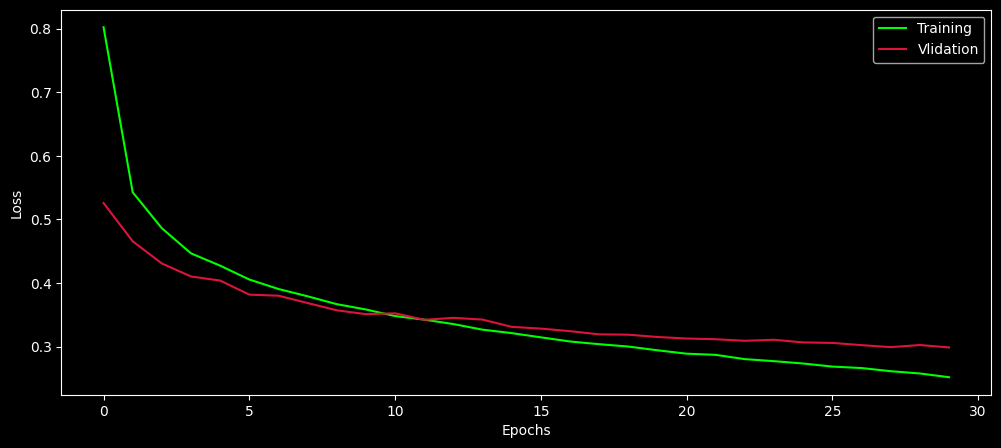

In [26]:
plt.figure(figsize = (12, 5))

plt.plot(history_FNN.history['loss'], color = 'lime', label = 'Training')
plt.plot(history_FNN.history['val_loss'], color = 'crimson', label = 'Vlidation')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

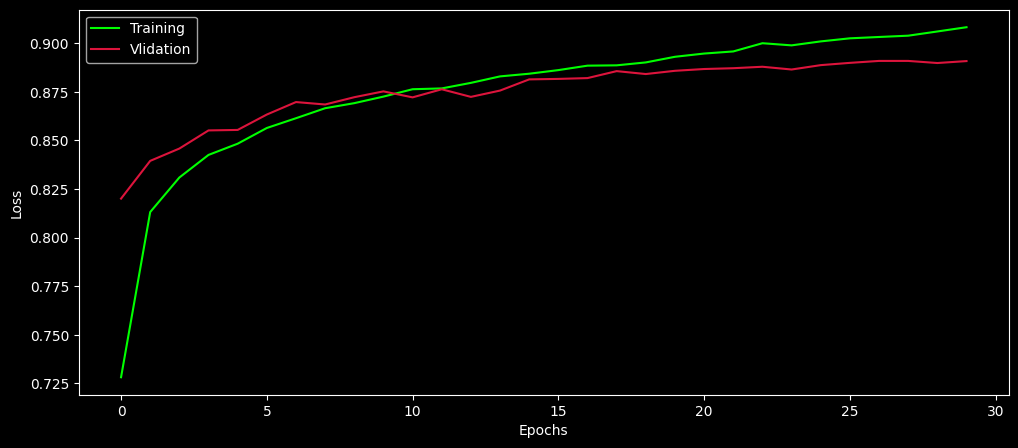

In [27]:
plt.figure(figsize = (12, 5))

plt.plot(history_FNN.history['accuracy'], color = 'lime', label = 'Training')
plt.plot(history_FNN.history['val_accuracy'], color = 'crimson', label = 'Vlidation')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [28]:
model.save("FNN_MNIST_model.keras")

In [29]:
load_model = tf.keras.models.load_model("/kaggle/working/FNN_MNIST_model.keras")

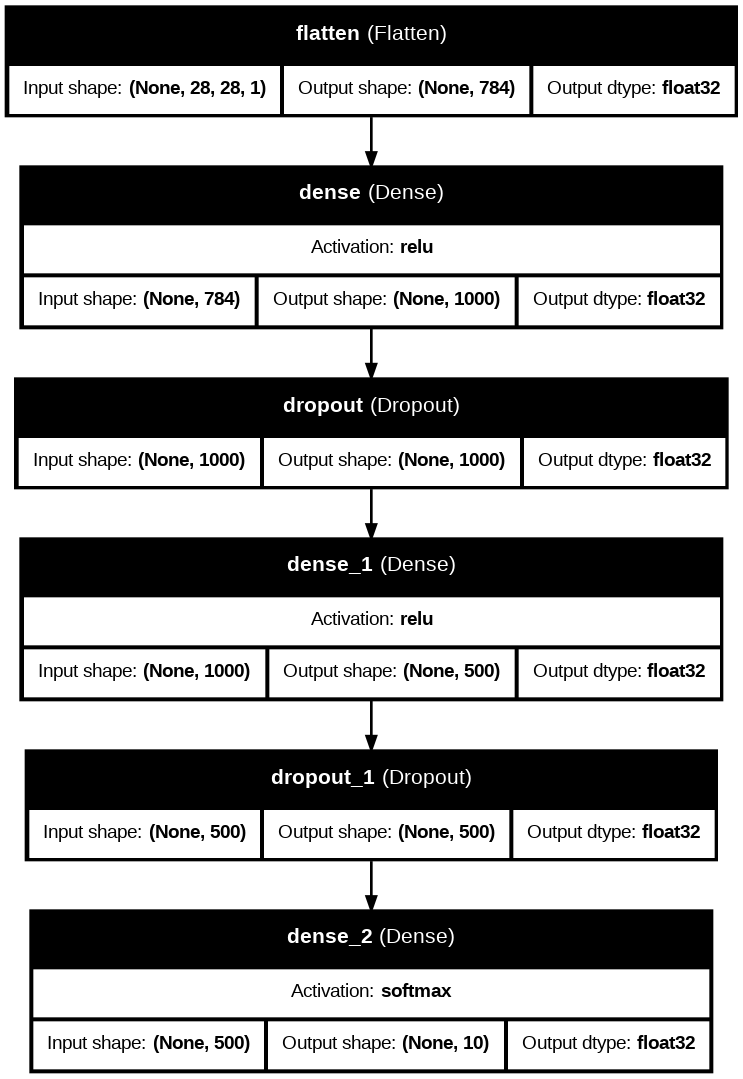

In [30]:
keras.utils.plot_model(
    model,
    to_file = "model.png",
    show_shapes = True,
    show_dtype = True,
    show_layer_names = True,
    rankdir="TB",
    expand_nested = True,
    dpi = 96,
    show_layer_activations = True,
    show_trainable=False,
)

In [31]:
train_loss, train_accuracy = load_model.evaluate(X_train_normalized, y_train)

print(f"Training Loss : {train_loss}")
print(f"Training Accuracy : {train_accuracy}")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9204 - loss: 0.2178
Training Loss : 0.23404747247695923
Training Accuracy : 0.9143666625022888


In [32]:
validation_loss, validation_accuracy = load_model.evaluate(X_test_normalized, y_test)

print(f"Training Loss : {validation_loss}")
print(f"Training Accuracy : {validation_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8876 - loss: 0.3219
Training Loss : 0.3227384686470032
Training Accuracy : 0.8870000243186951


In [33]:
predictions_one_hot = load_model.predict([X_test_normalized])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [34]:
print(f"predictions_one_hot : {predictions_one_hot.shape}")

predictions_one_hot : (10000, 10)


In [35]:
pd.DataFrame(predictions_one_hot)

,0,1,2,3,4,5,6,7,8,9
0,8.790271e-06,1.404420e-05,9.135241e-06,8.566017e-06,1.055029e-05,3.803787e-03,3.089891e-05,1.073113e-02,4.719588e-05,9.853359e-01
1,1.710812e-05,1.747824e-08,9.977797e-01,2.671893e-08,2.071407e-03,1.762110e-08,1.318358e-04,9.202250e-10,1.243899e-08,3.477592e-09
2,1.708184e-07,9.999998e-01,1.397107e-08,5.978373e-08,1.045028e-08,4.384227e-12,1.583541e-10,5.437602e-11,5.427286e-10,1.933810e-11
3,2.423903e-07,9.999915e-01,1.745614e-07,7.965729e-06,1.149586e-07,2.373271e-10,9.978669e-09,5.613657e-10,1.274391e-09,2.536547e-09
4,7.953645e-02,1.257776e-05,5.498990e-03,6.993612e-04,2.058318e-03,7.992590e-05,9.120160e-01,1.227588e-05,6.754968e-05,1.857177e-05
...,...,...,...,...,...,...,...,...,...,...
9995,1.369925e-08,2.546389e-08,7.335979e-09,1.396879e-09,2.178997e-09,4.768570e-06,2.479237e-08,6.612342e-05,4.708129e-09,9.999291e-01
9996,1.107585e-04,9.996606e-01,5.274874e-05,1.576823e-04,9.372335e-06,5.874787e-08,7.102245e-06,2.182711e-07,8.346034e-07,6.378137e-07
9997,3.600030e-03,9.752996e-08,4.196404e-04,3.078320e-04,3.410491e-04,1.168724e-05,2.396029e-04,3.862334e-06,9.950761e-01,7.872167e-08
9998,1.318164e-06,9.999492e-01,6.563200e-07,4.777458e-05,4.006395e-07,1.363857e-08,1.936367e-07,2.590536e-08,1.232892e-07,2.260515e-07


In [36]:
predictions_one_hot.sum(axis = 1)[0]

1.0

In [37]:
for i in range(10):
    print(f"{i} row sum is : {predictions_one_hot.sum(axis = 1)[0]}")

0 row sum is : 1.0
1 row sum is : 1.0
2 row sum is : 1.0
3 row sum is : 1.0
4 row sum is : 1.0
5 row sum is : 1.0
6 row sum is : 1.0
7 row sum is : 1.0
8 row sum is : 1.0
9 row sum is : 1.0


In [38]:
predictions = np.argmax(predictions_one_hot, axis = 1)
pd.DataFrame(predictions)

,0
0,9
1,2
2,1
3,1
4,6
...,...
9995,9
9996,1
9997,8
9998,1


In [39]:
for i in range(10):
    print(class_names[predictions[i]], end = ",")

Ankle boot,Pullover,Trouser,Trouser,Shirt,Trouser,Coat,Shirt,Sandal,Sneaker,

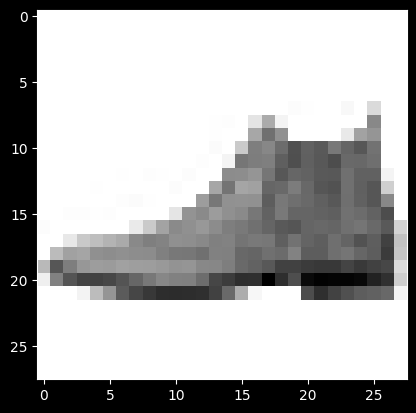

In [40]:
plt.imshow(X_test_normalized[0].reshape((IMAGE_WIDTH, IMAGE_HEIGHT)), cmap = plt.cm.binary)
plt.show()

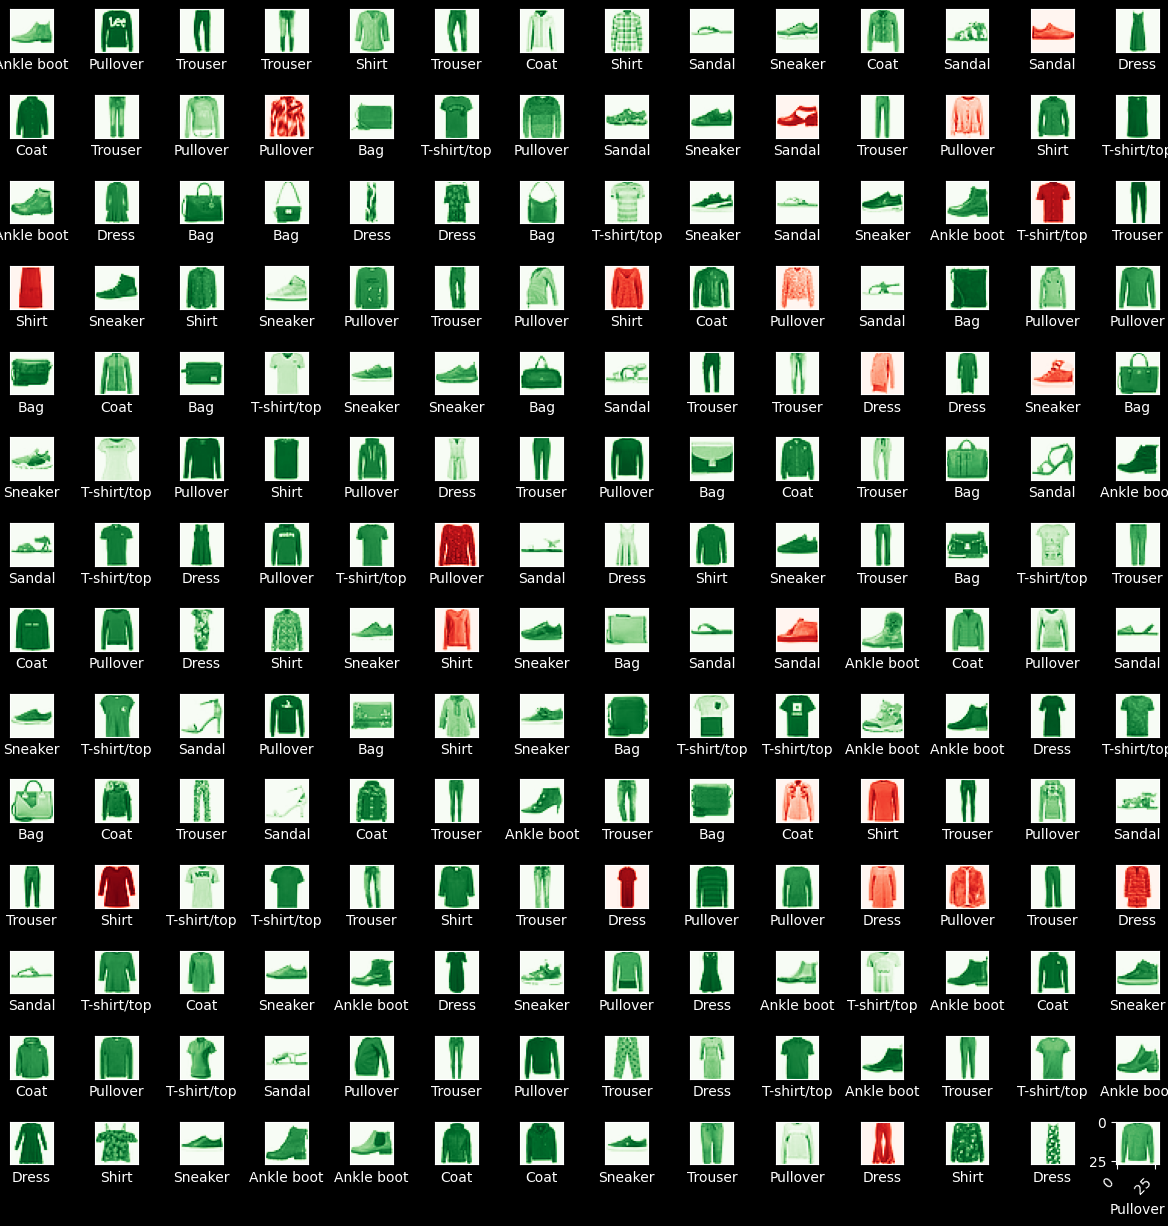

In [41]:
items_to_display = 196

num_cells = math.ceil(math.sqrt(items_to_display))
plt.figure(figsize = (15, 15))

for plot_index in range(items_to_display):
    predicted_label = predictions[plot_index]
    true_label = np.argmax(y_test[plot_index])

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    color_map = "Greens" if predicted_label == true_label else "Reds"

    plt.subplot(num_cells, num_cells, plot_index + 1)
    plt.imshow(
        X_test_normalized[plot_index].reshape((IMAGE_WIDTH, IMAGE_HEIGHT)),
        cmap = color_map
    )
    plt.xlabel(class_names[predicted_label])
    plt.xticks(rotation = 45, ha = 'right')

plt.subplots_adjust(hspace = 1, wspace = 0.5)
plt.show()

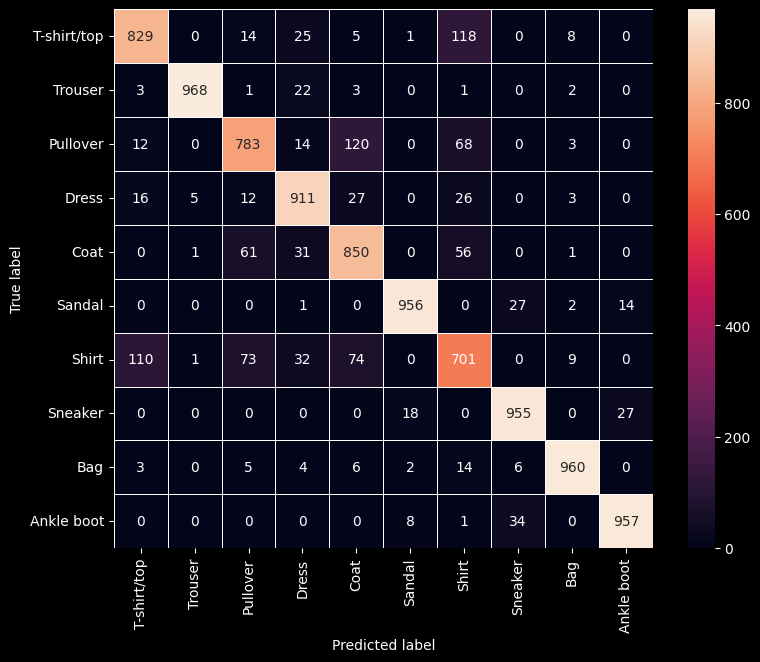

In [42]:
true_labels = np.argmax(y_test, axis = 1)

confusion_matrix = tf.math.confusion_matrix(
    true_labels,
    predictions
)

f, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    confusion_matrix,
    annot = True,
    linewidths = 0.5,
    fmt = "d",
    square = True,
    ax = ax,
    xticklabels = class_names,
    yticklabels = class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()